In [ ]:
from google.colab import files
import shutil, os

# print("Upload your local experiments/mlflow.db")
# uploaded = files.upload()

os.makedirs("experiments", exist_ok=True)
shutil.copy("mlflow.db", "experiments/mlflow.db")
print("mlflow.db ready ✓")

mlflow.db ready ✓


In [ ]:
!pip install -q medmnist mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.

In [ ]:
import os, random, time
import numpy as np
import torch
import torch.nn as nn
import mlflow
import mlflow.pytorch
import matplotlib.pyplot as plt
from torchvision import models, transforms
from torch.utils.data import DataLoader
from medmnist import ChestMNIST
from sklearn.metrics import roc_auc_score, f1_score
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

LABEL_NAMES = [
    'Atelectasis','Cardiomegaly','Effusion','Infiltration','Mass','Nodule',
    'Pneumonia','Pneumothorax','Consolidation','Edema','Emphysema',
    'Fibrosis','Pleural_Thickening','Hernia'
]
NUM_CLASSES = 14
BATCH_SIZE  = 64

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [ ]:
mlflow.set_tracking_uri("sqlite:///experiments/mlflow.db")
mlflow.set_experiment("mlops-chestmnist")
print("Tracking URI:", mlflow.get_tracking_uri())

2026/05/16 13:33:43 INFO mlflow.tracking.fluent: Experiment with name 'mlops-chestmnist' does not exist. Creating a new experiment.


Tracking URI: sqlite:///experiments/mlflow.db


In [ ]:
def get_transforms(split):
    norm = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    if split == "train":
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Grayscale(num_output_channels=3),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            norm,
        ])
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        norm,
    ])

g = torch.Generator().manual_seed(SEED)

train_ds = ChestMNIST(split="train", transform=get_transforms("train"), download=True)
val_ds   = ChestMNIST(split="val",   transform=get_transforms("val"),   download=True)
test_ds  = ChestMNIST(split="test",  transform=get_transforms("test"),  download=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, generator=g)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# pos_weight — same formula as W2
y_train    = train_ds.labels.astype(np.float32)
pos_counts = y_train.sum(axis=0)
neg_counts = len(y_train) - pos_counts
pos_weight = torch.tensor(neg_counts / np.maximum(pos_counts, 1), dtype=torch.float32)

print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}")
print(f"pos_weight range: [{pos_weight.min():.1f}, {pos_weight.max():.1f}]")

100%|██████████| 82.8M/82.8M [00:07<00:00, 11.7MB/s]


Train: 78,468 | Val: 11,219 | Test: 22,433
pos_weight range: [4.6, 543.9]


In [ ]:
class GrayscaleTo3Ch(nn.Module):
    def forward(self, x):
        return x.expand(-1, 3, -1, -1)

def build_finetuned_model(backbone='mobilenet_v2'):
    if backbone == 'mobilenet_v2':
        m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        m.classifier = nn.Linear(m.classifier[1].in_features, NUM_CLASSES)
    elif backbone == 'resnet18':
        m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)

    # ALL parameters trainable — no freezing
    for p in m.parameters():
        p.requires_grad = True

    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{backbone} | total: {total:,} | trainable: {trainable:,} (fully unfrozen)")
    return nn.Sequential(GrayscaleTo3Ch(), m)

In [ ]:
@torch.no_grad()
def evaluate(model, loader, pos_weight=None):
    model.eval()
    loss_fn = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight.to(device) if pos_weight is not None else None
    )
    all_logits, all_labels, total_loss = [], [], 0.0

    for x, y in loader:
        x, y = x.to(device), y.float().to(device)
        logits = model(x)
        total_loss += loss_fn(logits, y).item()
        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())

    logits_np = torch.cat(all_logits).numpy()
    labels_np = torch.cat(all_labels).numpy()
    probs_np  = torch.sigmoid(torch.tensor(logits_np)).numpy()
    preds_np  = (probs_np >= 0.5).astype(int)

    per_auc = [
        roc_auc_score(labels_np[:, i], probs_np[:, i])
        if labels_np[:, i].sum() > 0 else float('nan')
        for i in range(NUM_CLASSES)
    ]
    return {
        'macro_auc': np.nanmean(per_auc),
        'per_auc':   per_auc,
        'macro_f1':  f1_score(labels_np, preds_np, average='macro', zero_division=0),
        'loss':      total_loss / len(loader),
        'probs':     probs_np,
        'labels':    labels_np,
    }

In [ ]:
def train_finetuned(backbone='mobilenet_v2', num_epochs=10, lr=1e-4, lr_head=1e-3):
    """
    Full fine-tuning.
    - Backbone: lr=1e-4  (small — pretrained weights, don't destroy them)
    - Head:     lr=1e-3  (larger — randomly initialised)
    - ReduceLROnPlateau on val_loss, patience=2
    - Saves best checkpoint by val macro-AUC
    """
    run_name  = f"{backbone}_finetuned"
    ckpt_path = f"models/{run_name}_best.pth"
    os.makedirs("models",  exist_ok=True)
    os.makedirs("figures", exist_ok=True)

    model = build_finetuned_model(backbone).to(device)

    # Separate param groups: head gets higher LR
    if backbone == 'mobilenet_v2':
        head_params = list(model[1].classifier.parameters())
    else:
        head_params = list(model[1].fc.parameters())

    head_ids        = set(id(p) for p in head_params)
    backbone_params = [p for p in model.parameters() if id(p) not in head_ids]

    optimizer = torch.optim.Adam([
        {'params': backbone_params, 'lr': lr},
        {'params': head_params,     'lr': lr_head},
    ])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2
    )
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

    history      = {'train_loss': [], 'val_loss': [], 'val_macro_auc': [], 'val_macro_f1': []}
    best_val_auc = 0.0

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({
            'backbone':    backbone,
            'strategy':    'full_finetuning',
            'epochs':      num_epochs,
            'lr_backbone': lr,
            'lr_head':     lr_head,
            'batch_size':  BATCH_SIZE,
            'loss':        'BCE+pos_weight',
            'seed':        SEED,
            'scheduler':   'ReduceLROnPlateau_patience2',
            'image_size':  224,
        })

        for epoch in range(1, num_epochs + 1):
            # ── Train ──────────────────────────────────────────────────────────
            model.train()
            train_loss = 0.0
            for x, y in tqdm(train_loader, desc=f"[{backbone}] Epoch {epoch}/{num_epochs}", leave=False):
                x, y = x.to(device), y.float().to(device)
                optimizer.zero_grad()
                loss = loss_fn(model(x), y)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            avg_train_loss = train_loss / len(train_loader)

            # ── Validate ────────────────────────────────────────────────────────
            val_metrics = evaluate(model, val_loader, pos_weight)
            scheduler.step(val_metrics['loss'])

            history['train_loss'].append(avg_train_loss)
            history['val_loss'].append(val_metrics['loss'])
            history['val_macro_auc'].append(val_metrics['macro_auc'])
            history['val_macro_f1'].append(val_metrics['macro_f1'])

            # ── MLflow ─────────────────────────────────────────────────────────
            mlflow.log_metrics({
                'train_loss':    avg_train_loss,
                'val_loss':      val_metrics['loss'],
                'val_macro_auc': val_metrics['macro_auc'],
                'val_macro_f1':  val_metrics['macro_f1'],
                'lr_backbone':   optimizer.param_groups[0]['lr'],
                'lr_head':       optimizer.param_groups[1]['lr'],
            }, step=epoch)
            for i, name in enumerate(LABEL_NAMES):
                if not np.isnan(val_metrics['per_auc'][i]):
                    mlflow.log_metric(f'val_auc_{name}', val_metrics['per_auc'][i], step=epoch)

            print(
                f"Epoch {epoch:02d} | train_loss={avg_train_loss:.4f} "
                f"| val_loss={val_metrics['loss']:.4f} "
                f"| val_AUC={val_metrics['macro_auc']:.4f} "
                f"| val_F1={val_metrics['macro_f1']:.4f}"
            )

            # ── Save best checkpoint ────────────────────────────────────────────
            if val_metrics['macro_auc'] > best_val_auc:
                best_val_auc = val_metrics['macro_auc']
                torch.save(model.state_dict(), ckpt_path)
                mlflow.log_artifact(ckpt_path)
                print(f"  ✓ New best val AUC: {best_val_auc:.4f} — checkpoint saved")

        # ── Test set evaluation ─────────────────────────────────────────────────
        model.load_state_dict(torch.load(ckpt_path))   # load best
        test_metrics = evaluate(model, test_loader, pos_weight)
        mlflow.log_metrics({
            'test_macro_auc': test_metrics['macro_auc'],
            'test_macro_f1':  test_metrics['macro_f1'],
        })
        for i, name in enumerate(LABEL_NAMES):
            if not np.isnan(test_metrics['per_auc'][i]):
                mlflow.log_metric(f'test_auc_{name}', test_metrics['per_auc'][i])

        print(f"\n{'='*55}")
        print(f"  {backbone} fine-tuning complete")
        print(f"  Best val AUC : {best_val_auc:.4f}")
        print(f"  Test AUC     : {test_metrics['macro_auc']:.4f}")
        print(f"  Test F1      : {test_metrics['macro_f1']:.4f}")
        print(f"{'='*55}")

    return model, test_metrics, history

In [ ]:
model_mv2, test_mv2, history_mv2 = train_finetuned(
    backbone='mobilenet_v2', num_epochs=10, lr=1e-4, lr_head=1e-3
)

mobilenet_v2 | total: 2,241,806 | trainable: 2,241,806 (fully unfrozen)


Epoch 01 | train_loss=1.2085 | val_loss=1.1301 | val_AUC=0.7547 | val_F1=0.1511
  ✓ New best val AUC: 0.7547 — checkpoint saved


Epoch 02 | train_loss=1.1114 | val_loss=1.1166 | val_AUC=0.7631 | val_F1=0.1604
  ✓ New best val AUC: 0.7631 — checkpoint saved


Epoch 03 | train_loss=1.0764 | val_loss=1.1280 | val_AUC=0.7584 | val_F1=0.1611


Epoch 04 | train_loss=1.0429 | val_loss=1.0829 | val_AUC=0.7745 | val_F1=0.1753
  ✓ New best val AUC: 0.7745 — checkpoint saved


...

Epoch 06 | train_loss=0.9942 | val_loss=1.2313 | val_AUC=0.7734 | val_F1=0.1709


Epoch 07 | train_loss=0.9702 | val_loss=1.1805 | val_AUC=0.7795 | val_F1=0.1783
  ✓ New best val AUC: 0.7795 — checkpoint saved


Epoch 08 | train_loss=0.9126 | val_loss=1.2590 | val_AUC=0.7847 | val_F1=0.1828
  ✓ New best val AUC: 0.7847 — checkpoint saved


Epoch 09 | train_loss=0.8880 | val_loss=1.4315 | val_AUC=0.7817 | val_F1=0.1874


Epoch 10 | train_loss=0.8692 | val_loss=1.3893 | val_AUC=0.7827 | val_F1=0.1922

  mobilenet_v2 fine-tuning complete
  Best val AUC : 0.7847
  Test AUC     : 0.7920
  Test F1      : 0.1898


In [ ]:
model_rn18, test_rn18, history_rn18 = train_finetuned(
    backbone='resnet18', num_epochs=10, lr=1e-4, lr_head=1e-3
)

resnet18 | total: 11,183,694 | trainable: 11,183,694 (fully unfrozen)


Epoch 01 | train_loss=1.2105 | val_loss=1.1653 | val_AUC=0.7535 | val_F1=0.1537
  ✓ New best val AUC: 0.7535 — checkpoint saved


Epoch 02 | train_loss=1.1183 | val_loss=1.1554 | val_AUC=0.7648 | val_F1=0.1685
  ✓ New best val AUC: 0.7648 — checkpoint saved


Epoch 03 | train_loss=1.0832 | val_loss=1.1116 | val_AUC=0.7726 | val_F1=0.1665
  ✓ New best val AUC: 0.7726 — checkpoint saved


Epoch 04 | train_loss=1.0422 | val_loss=1.1369 | val_AUC=0.7620 | val_F1=0.1568


...

Epoch 06 | train_loss=1.0018 | val_loss=1.1179 | val_AUC=0.7727 | val_F1=0.1806


Epoch 07 | train_loss=0.9620 | val_loss=1.2775 | val_AUC=0.7871 | val_F1=0.1816
  ✓ New best val AUC: 0.7871 — checkpoint saved


Epoch 08 | train_loss=0.9437 | val_loss=1.1918 | val_AUC=0.7752 | val_F1=0.1735


Epoch 09 | train_loss=0.8503 | val_loss=1.2460 | val_AUC=0.7909 | val_F1=0.1865
  ✓ New best val AUC: 0.7909 — checkpoint saved


Epoch 10 | train_loss=0.7921 | val_loss=1.5214 | val_AUC=0.7785 | val_F1=0.1911

  resnet18 fine-tuning complete
  Best val AUC : 0.7909
  Test AUC     : 0.7885
  Test F1      : 0.1877


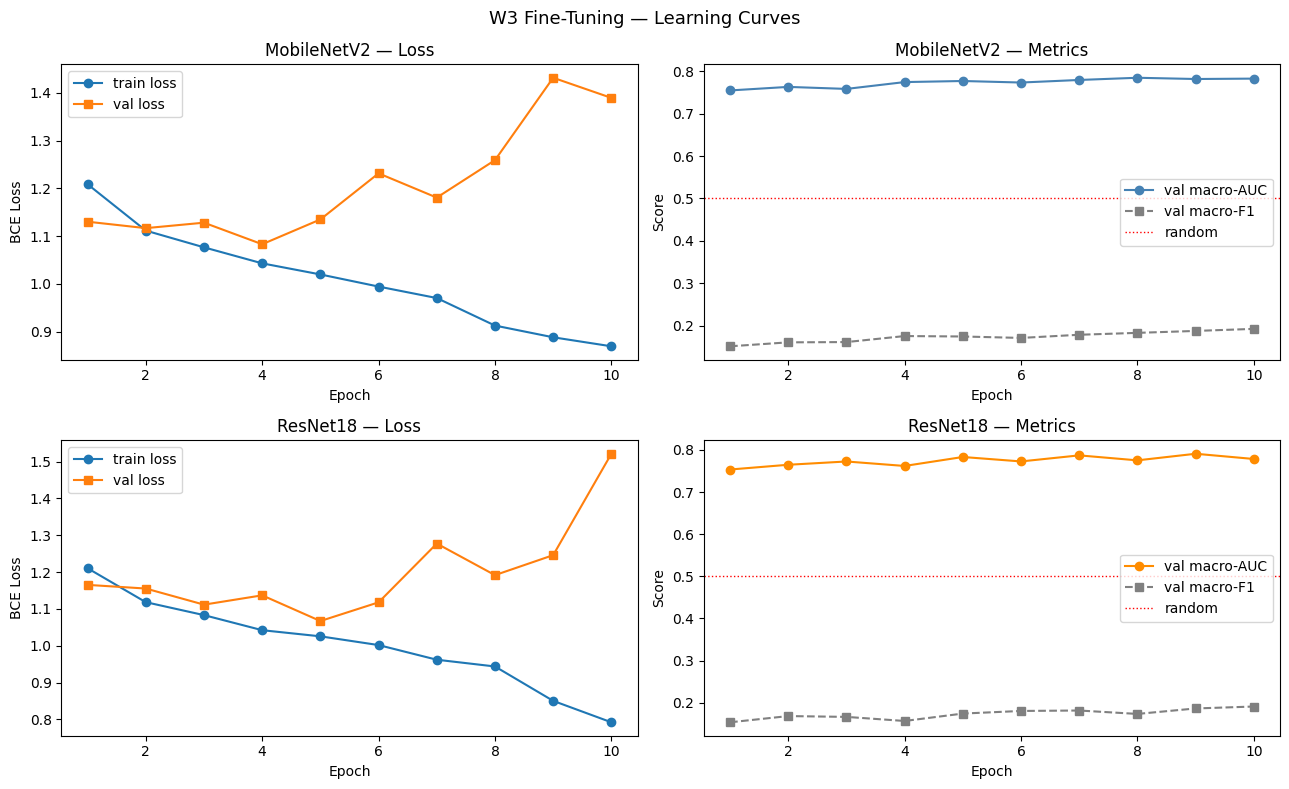

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
epochs = range(1, len(history_mv2['train_loss']) + 1)

for row, (hist, name, color) in enumerate([
    (history_mv2,  'MobileNetV2', 'steelblue'),
    (history_rn18, 'ResNet18',    'darkorange'),
]):
    ax_loss, ax_auc = axes[row]

    ax_loss.plot(epochs, hist['train_loss'], 'o-', label='train loss')
    ax_loss.plot(epochs, hist['val_loss'],   's-', label='val loss')
    ax_loss.set_title(f"{name} — Loss")
    ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("BCE Loss")
    ax_loss.legend()

    ax_auc.plot(epochs, hist['val_macro_auc'], 'o-', color=color,  label='val macro-AUC')
    ax_auc.plot(epochs, hist['val_macro_f1'],  's--', color='gray', label='val macro-F1')
    ax_auc.axhline(0.5, color='red', linestyle=':', linewidth=1, label='random')
    ax_auc.set_title(f"{name} — Metrics")
    ax_auc.set_xlabel("Epoch"); ax_auc.set_ylabel("Score")
    ax_auc.legend()

plt.suptitle("W3 Fine-Tuning — Learning Curves", fontsize=13)
plt.tight_layout()
plt.savefig("figures/finetuned_learning_curves.png", dpi=150)
plt.show()

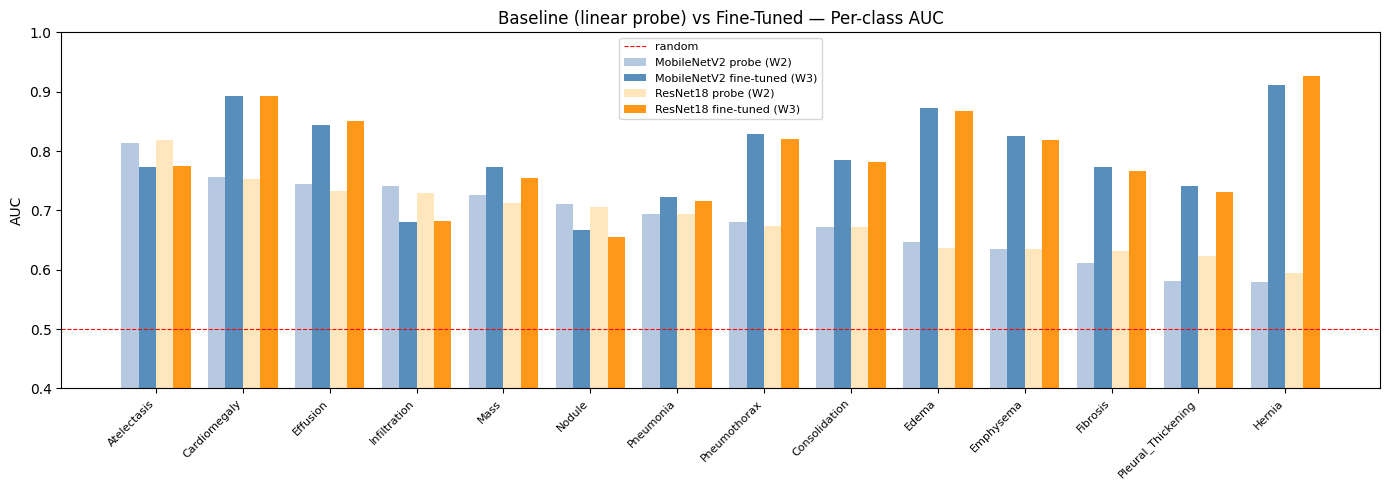


Model                            W2 AUC   W3 AUC   Delta
-------------------------------------------------------
MobileNetV2 linear probe         0.6852   0.7920 +0.1068
ResNet18 linear probe            0.6865   0.7885 +0.1020


In [ ]:
# W2 baseline results — paste your actual numbers here
baseline_mv2  = [0.8143,0.7566,0.7445,0.7407,0.7254,0.7106,0.6938,0.6810,0.6723,0.6469,0.6346,0.6118,0.5814,0.5787]
baseline_rn18 = [0.8192,0.7521,0.7320,0.7301,0.7132,0.7052,0.6940,0.6731,0.6716,0.6367,0.6342,0.6315,0.6228,0.5947]

x     = np.arange(NUM_CLASSES)
width = 0.2
labels_sorted = LABEL_NAMES

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - 1.5*width, baseline_mv2,              width, label='MobileNetV2 probe (W2)',    color='lightsteelblue', alpha=0.9)
ax.bar(x - 0.5*width, test_mv2['per_auc'],        width, label='MobileNetV2 fine-tuned (W3)', color='steelblue',      alpha=0.9)
ax.bar(x + 0.5*width, baseline_rn18,              width, label='ResNet18 probe (W2)',       color='moccasin',       alpha=0.9)
ax.bar(x + 1.5*width, test_rn18['per_auc'],       width, label='ResNet18 fine-tuned (W3)',  color='darkorange',     alpha=0.9)
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='random')
ax.set_xticks(x)
ax.set_xticklabels(LABEL_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("AUC"); ax.set_ylim(0.4, 1.0)
ax.set_title("Baseline (linear probe) vs Fine-Tuned — Per-class AUC")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/finetuned_vs_baseline_per_class_auc.png", dpi=150)
plt.show()

# Summary table
print(f"\n{'Model':<30} {'W2 AUC':>8} {'W3 AUC':>8} {'Delta':>7}")
print("-" * 55)
print(f"{'MobileNetV2 linear probe':<30} {'0.6852':>8} {test_mv2['macro_auc']:>8.4f} {test_mv2['macro_auc']-0.6852:>+7.4f}")
print(f"{'ResNet18 linear probe':<30} {'0.6865':>8} {test_rn18['macro_auc']:>8.4f} {test_rn18['macro_auc']-0.6865:>+7.4f}")

In [ ]:
import shutil
from google.colab import files

os.makedirs("to_download/figures",     exist_ok=True)
os.makedirs("to_download/models",      exist_ok=True)
os.makedirs("to_download/experiments", exist_ok=True)

for fname in [
    "finetuned_learning_curves.png",
    "finetuned_vs_baseline_per_class_auc.png",
]:
    shutil.copy(f"figures/{fname}", "to_download/figures/")

shutil.copy("experiments/mlflow.db",                    "to_download/experiments/mlflow.db")
shutil.copy("models/mobilenet_v2_finetuned_best.pth",   "to_download/models/")
shutil.copy("models/resnet18_finetuned_best.pth",       "to_download/models/")

shutil.make_archive("w3_finetuning_artifacts", "zip", "to_download")
files.download("w3_finetuning_artifacts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>